# Impact of Gaming Behavior on Academic and Psychological Outcomes
**Big Data Analysis: Data Science Project**  
Akhmadjonov Sh

## 1. Data Loading

The dataset is loaded from a CSV file containing 1005 rows and 39 columns, covering gaming habits, psychological scores, and health metrics of individual players.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving data_4.csv to data_4.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data_4.csv")

## 2. Dataset Overview

Below we inspect the first rows, data types, and basic statistics to understand the structure and value ranges of each feature.

In [3]:
df.head()

,age,gender,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,...,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality
0,51,Female,8615,3.68,22,17,5.26,1.00,0.18,3,...,0,2.87,3.19,5.20,19.69,4.71,5.71,4.81,80,10
1,41,Female,39453,5.70,34,16,9.20,0.70,1.44,8,...,7,4.17,7.73,5.40,26.37,6.62,6.77,3.99,57,2
2,27,Male,40466,1.58,8,22,7.39,2.24,3.15,3,...,9,9.38,2.85,5.17,25.15,9.30,2.16,4.75,59,10
3,55,Male,51076,6.11,39,24,7.99,1.65,2.80,1,...,5,8.24,7.19,8.62,26.42,13.81,4.72,5.37,89,1
4,20,Male,86116,3.65,17,0,7.12,1.02,1.01,2,...,9,6.65,2.53,9.71,25.75,10.74,3.90,6.44,15,10


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         1005 non-null   int64  
 1   gender                      1005 non-null   object 
 2   income                      1005 non-null   int64  
 3   daily_gaming_hours          1005 non-null   float64
 4   weekly_sessions             1005 non-null   int64  
 5   years_gaming                1005 non-null   int64  
 6   sleep_hours                 1005 non-null   float64
 7   caffeine_intake             1005 non-null   float64
 8   exercise_hours              1005 non-null   float64
 9   stress_level                1005 non-null   int64  
 10  anxiety_score               1005 non-null   float64
 11  depression_score            1005 non-null   float64
 12  social_interaction_score    1005 non-null   float64
 13  relationship_satisfaction   1005 

In [5]:
df.describe()

,age,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,anxiety_score,...,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality
count,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,...,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.00000
mean,35.942289,76684.697512,3.944657,19.523383,11.758209,6.992338,2.060537,1.999582,5.416915,4.830438,...,5.109453,4.976090,4.956468,5.999393,24.186219,7.925264,5.045990,3.982995,49.895522,5.60995
std,13.515988,41555.712105,2.877536,11.319372,7.206836,1.482334,2.054700,2.043844,2.865913,1.929894,...,3.157859,1.941267,1.993696,1.931674,3.986858,4.020046,1.972545,1.936471,28.836778,2.88441
min,13.000000,5025.000000,0.070000,1.000000,0.000000,2.940000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,11.070000,0.580000,0.000000,0.000000,0.000000,1.00000
25%,24.000000,40754.000000,1.790000,10.000000,5.000000,5.990000,0.580000,0.540000,3.000000,3.480000,...,2.000000,3.640000,3.620000,4.700000,21.500000,4.950000,3.700000,2.730000,26.000000,3.00000
50%,37.000000,75490.000000,3.290000,20.000000,12.000000,6.980000,1.390000,1.400000,5.000000,4.870000,...,5.000000,4.900000,5.030000,5.990000,24.150000,7.390000,5.070000,3.940000,49.000000,6.00000
75%,47.000000,112442.000000,5.460000,29.000000,18.000000,7.950000,2.870000,2.800000,8.000000,6.080000,...,8.000000,6.230000,6.240000,7.340000,26.800000,10.250000,6.380000,5.270000,75.000000,8.00000
max,59.000000,149698.000000,17.660000,39.000000,24.000000,11.490000,12.080000,15.800000,10.000000,10.000000,...,10.000000,10.000000,10.000000,10.000000,37.030000,32.560000,10.000000,10.000000,99.000000,10.00000


## 3. Data Quality Check

We verify that the dataset has no missing values and no duplicate rows. Both checks return zero, meaning the data is clean and ready for preprocessing.

In [6]:
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


## 4. Data Preprocessing

### 4.1 Encoding the Gender Feature

The gender column is the only categorical feature in the dataset. We apply OneHotEncoder to convert it into three binary columns: gender_Female, gender_Male, and gender_Other. This approach avoids any implied ordinal relationship between categories.

In [7]:
from sklearn.preprocessing import OneHotEncoder

my_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False).set_output(transform="pandas")
gender_transform = my_encoder.fit_transform(df[['gender']])
gender_transform.head()

,gender_Female,gender_Male,gender_Other
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,1.0,0.0


### 4.2 Creating the Addiction Category (Classification Target)

The addiction_level column contains continuous decimal values ranging from 0 to 10. Since it cannot be used directly as a classification target, we bin it into three balanced categories using quantile-based boundaries. This ensures each category (Low, Medium, High) contains approximately equal numbers of rows, preventing class imbalance in the classification models.

Boundaries used: Low: 0 to 1.58, Medium: 1.58 to 3.41, High: 3.41 to 10.

In [8]:
from sklearn.preprocessing import LabelEncoder

bins = [0, 1.5832, 3.4092, 10]
labels = ["Low", "Medium", "High"]

df["addiction_category"] = pd.cut(df["addiction_level"], bins=bins, labels=labels, include_lowest=True)

le = LabelEncoder()
df["addiction_category_encoded"] = le.fit_transform(df["addiction_category"])

print(df["addiction_category"].value_counts())

addiction_category
High      342
Low       332
Medium    331
Name: count, dtype: int64


### 4.3 Defining Feature Sets and Targets

Two separate feature sets are defined: one for regression and one for classification. The regression set includes addiction_level as an input feature since it is an independent measurement. The classification set excludes addiction_level to avoid data leakage, as the target (addiction_category_encoded) was directly derived from it. Academic performance is included as a feature in the classification set since it is an independent variable.

Gender encoded columns are concatenated into both feature sets.

In [9]:
x_reg = df[['age', 'income', 'daily_gaming_hours', 'weekly_sessions', 'years_gaming',
            'weekend_gaming_hours', 'sleep_hours', 'caffeine_intake', 'exercise_hours',
            'stress_level', 'anxiety_score', 'depression_score', 'social_interaction_score',
            'relationship_satisfaction', 'loneliness_score', 'aggression_score', 'happiness_score',
            'bmi', 'screen_time_total', 'eye_strain_score', 'back_pain_score', 'streaming_hours',
            'microtransactions_spending', 'friends_gaming_count', 'online_friends',
            'competitive_rank', 'internet_quality', 'esports_interest', 'parental_supervision',
            'addiction_level']]
x_reg = pd.concat([x_reg, gender_transform], axis=1)
y_reg = df['academic_performance']

x_clf = df[['age', 'income', 'daily_gaming_hours', 'weekly_sessions', 'years_gaming',
            'weekend_gaming_hours', 'sleep_hours', 'caffeine_intake', 'exercise_hours',
            'stress_level', 'anxiety_score', 'depression_score', 'social_interaction_score',
            'relationship_satisfaction', 'loneliness_score', 'aggression_score', 'happiness_score',
            'bmi', 'screen_time_total', 'eye_strain_score', 'back_pain_score', 'streaming_hours',
            'microtransactions_spending', 'friends_gaming_count', 'online_friends',
            'competitive_rank', 'internet_quality', 'esports_interest', 'parental_supervision',
            'academic_performance']]
x_clf = pd.concat([x_clf, gender_transform], axis=1)
y_clf = df['addiction_category_encoded']

### 4.4 Train and Test Split

The dataset is split into 80% training and 20% test sets using random_state=42 for reproducibility. For classification, stratify=y_clf ensures that each addiction category is proportionally represented in both the training and test sets.

In [10]:
from sklearn.model_selection import train_test_split

x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(
    x_reg, y_reg, test_size=0.2, random_state=42)

x_train_clf, x_test_clf, y_train_clf, y_test_clf = train_test_split(
    x_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

print("Regression train/test shapes:", x_train_reg.shape, x_test_reg.shape)
print("Classification train/test shapes:", x_train_clf.shape, x_test_clf.shape)

Regression train/test shapes: (804, 33) (201, 33)
Classification train/test shapes: (804, 33) (201, 33)


### 4.5 Feature Scaling

StandardScaler is applied to normalize feature values across different scales. Features such as income (range: 5000 to 150000) and sleep_hours (range: 3 to 11) exist on very different scales. Without scaling, distance-based and gradient-based models would be dominated by large-range features.

Important: the scaler is fitted only on the training set and then applied to the test set. Fitting on test data would constitute data leakage.

In [11]:
from sklearn.preprocessing import StandardScaler

scale_reg = StandardScaler()
x_train_reg_scaled = scale_reg.fit_transform(x_train_reg)
x_test_reg_scaled  = scale_reg.transform(x_test_reg)

scale_clf = StandardScaler()
x_train_clf_scaled = scale_clf.fit_transform(x_train_clf)
x_test_clf_scaled  = scale_clf.transform(x_test_clf)

## 5. Data Visualization

Five visualizations are presented to explore the dataset and identify patterns relevant to the research question.

### Visual 1: Distribution of Academic Performance

This histogram shows the distribution of academic performance scores across all students. The KDE curve reveals a roughly uniform spread between 40 and 100, with no strong skew. This informs the choice of regression as the prediction approach.

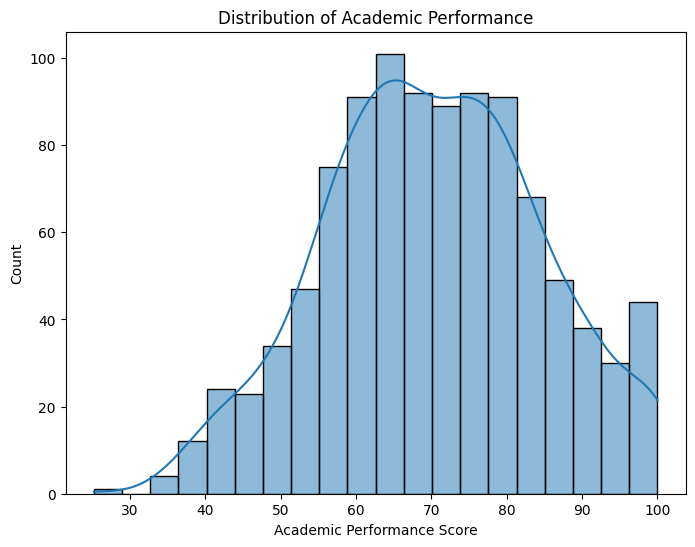

In [12]:
plt.figure(figsize=(8, 6))
sns.histplot(df['academic_performance'], bins=20, kde=True)
plt.title('Distribution of Academic Performance')
plt.xlabel('Academic Performance Score')
plt.ylabel('Count')
plt.show()

### Visual 2: Correlation Heatmap

The heatmap displays pairwise Pearson correlations between all numeric features. Notable findings: daily_gaming_hours and screen_time_total show a very strong correlation (0.73), and addiction_level also correlates strongly with both. Academic performance shows very weak correlations with all gaming features, which anticipates the low R2 scores in the regression models.

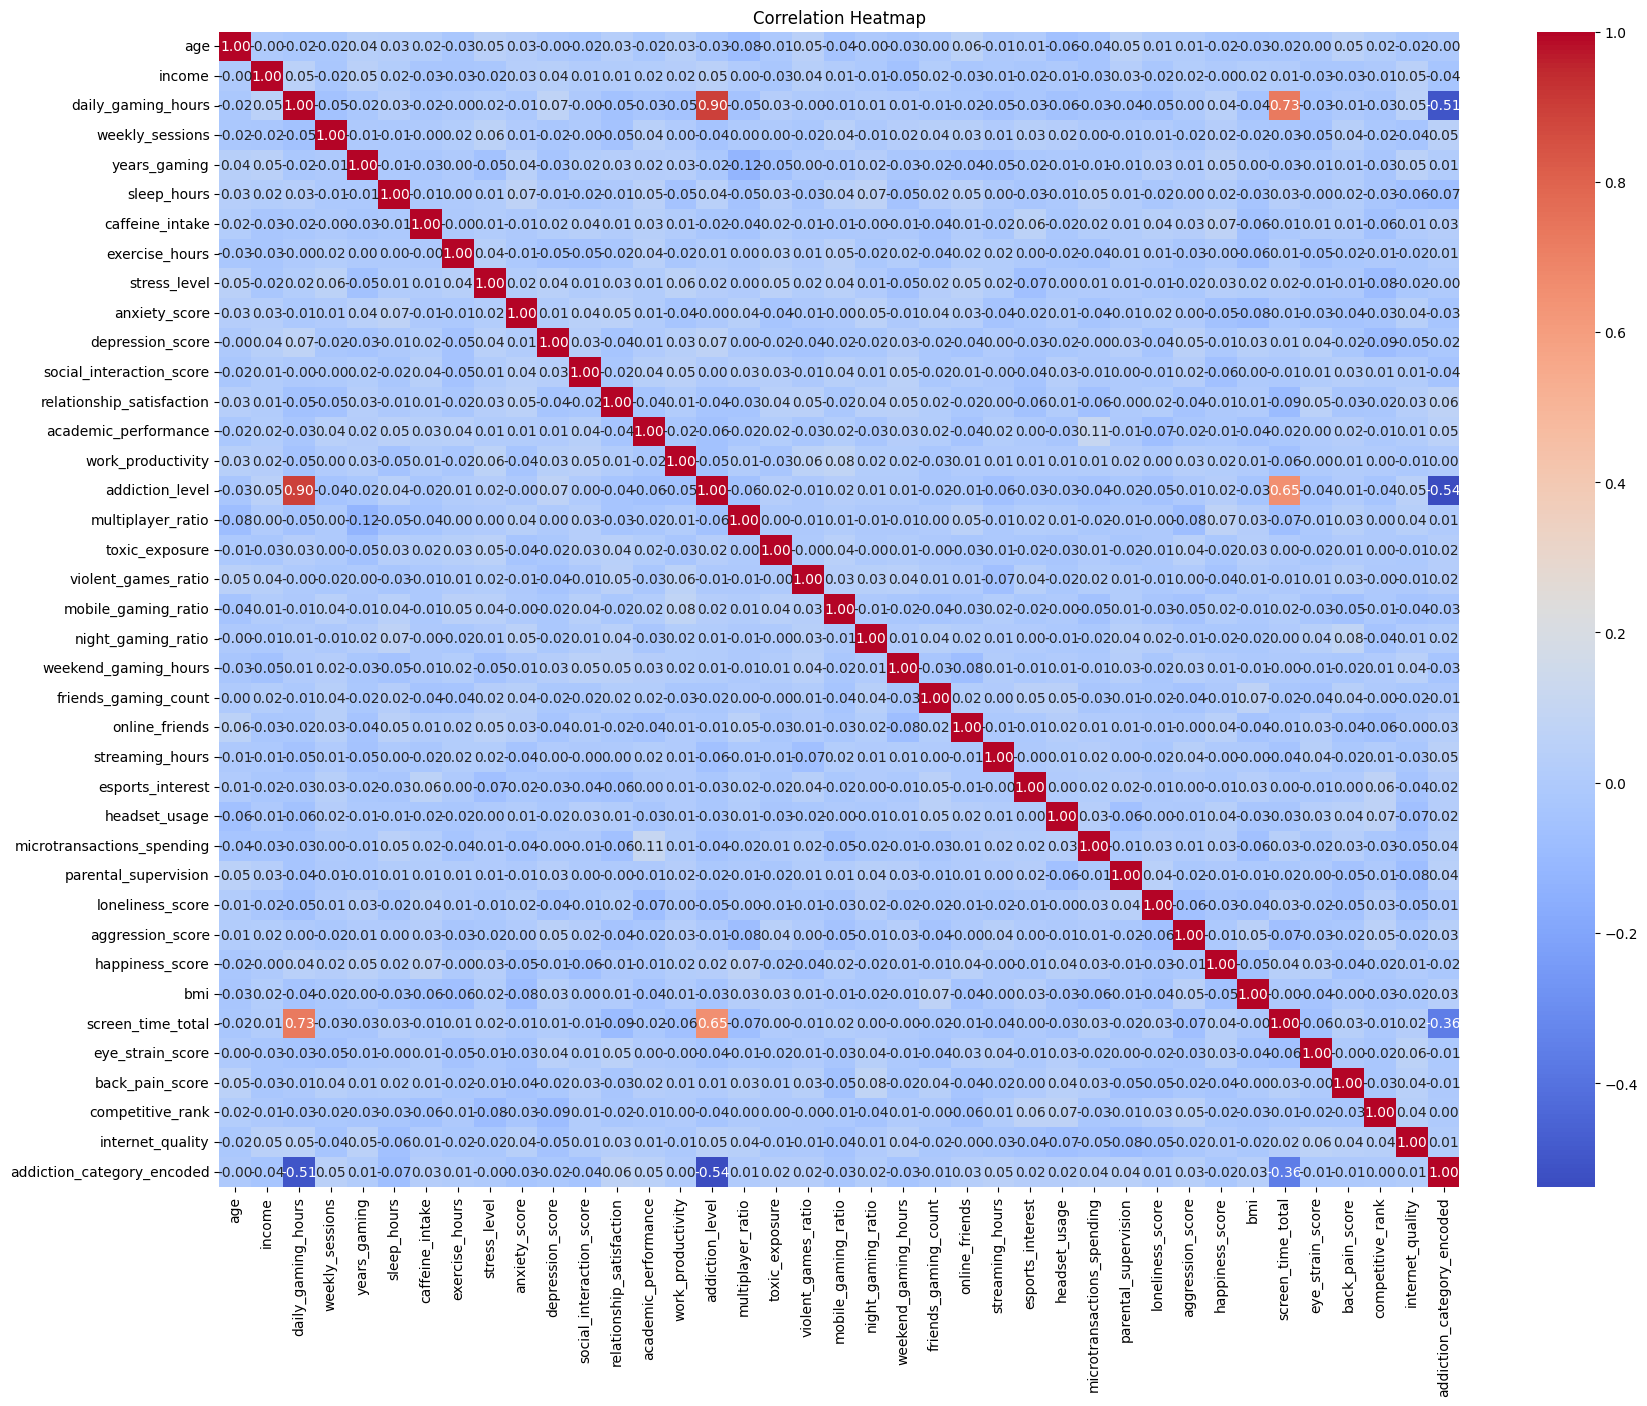

In [13]:
plt.figure(figsize=(20, 15))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### Visual 3: Daily Gaming Hours vs Academic Performance

This scatter plot examines the direct relationship between daily gaming time and academic performance. The lack of a clear trend confirms the near-zero correlation observed in the heatmap, suggesting gaming hours alone do not linearly predict academic outcomes.

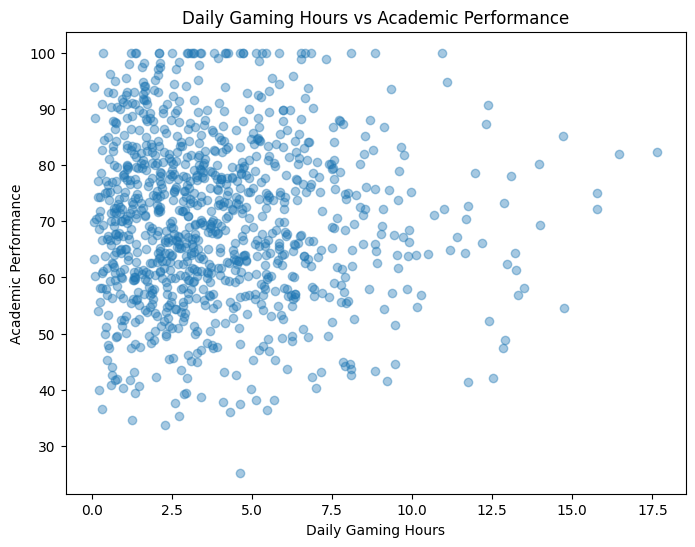

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(df['daily_gaming_hours'], df['academic_performance'], alpha=0.4)
plt.title('Daily Gaming Hours vs Academic Performance')
plt.xlabel('Daily Gaming Hours')
plt.ylabel('Academic Performance')
plt.show()

### Visual 4: Academic Performance by Addiction Category

This boxplot compares academic performance distributions across the three addiction categories. The medians and spreads are very similar across Low, Medium, and High groups, reinforcing that addiction level alone does not strongly differentiate academic outcomes in this dataset.

<Figure size 1000x600 with 0 Axes>

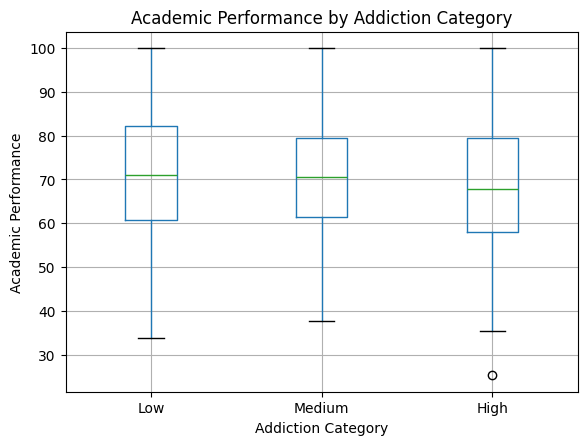

In [15]:
plt.figure(figsize=(10, 6))
df.boxplot(column='academic_performance', by='addiction_category')
plt.title('Academic Performance by Addiction Category')
plt.suptitle('')
plt.xlabel('Addiction Category')
plt.ylabel('Academic Performance')
plt.show()

### Visual 5: Psychological Score Correlations

This focused heatmap examines the correlations between anxiety_score, depression_score, stress_level, and addiction_level. The weak inter-correlations confirm that these psychological indicators are largely independent of addiction level in this dataset, which explains the modest classification accuracy obtained.

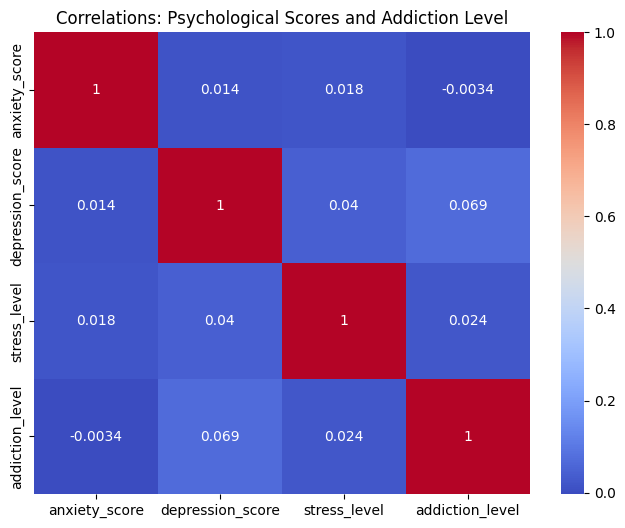

In [16]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['anxiety_score', 'depression_score', 'stress_level', 'addiction_level']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlations: Psychological Scores and Addiction Level')
plt.show()

## 6. Clustering

Clustering is applied to identify natural groupings in the data without using any target variable. The full scaled feature set (x_reg) is used because clustering benefits from all available behavioral and psychological features. Both algorithms use the full dataset to assign a cluster label to every row.

### 6.1 K-Means Clustering

The Elbow Method is used to determine the optimal number of clusters. Inertia (within-cluster sum of squares) is computed for K values from 2 to 10. The point where the rate of decrease slows significantly indicates the best K.

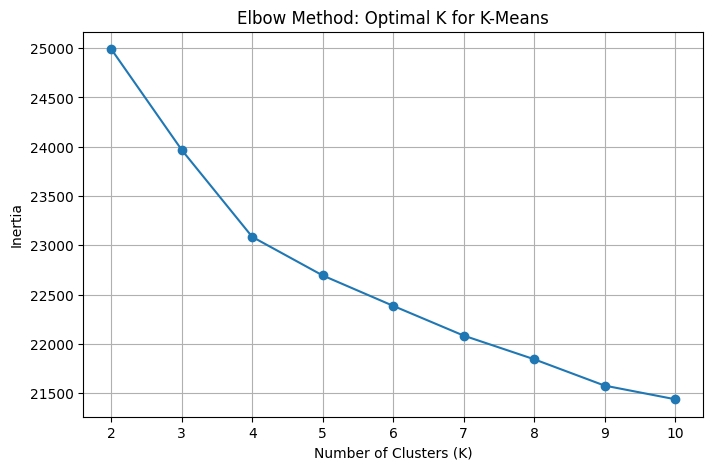

In [17]:
from sklearn.cluster import KMeans

x_reg_full_scaled = scale_reg.transform(x_reg)

inertia = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(x_train_reg_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method: Optimal K for K-Means')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

Based on the elbow plot, K=3 is selected as it provides a good balance between cluster compactness and model simplicity. Three clusters align naturally with the three addiction categories identified earlier.

In [18]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(x_train_reg_scaled)

df_cluster = df.copy()
df_cluster['kmeans_cluster'] = kmeans.predict(x_reg_full_scaled)

print("K-Means cluster distribution:")
print(df_cluster['kmeans_cluster'].value_counts())

K-Means cluster distribution:
kmeans_cluster
2    428
1    411
0    166
Name: count, dtype: int64


### 6.2 Hierarchical Clustering

Agglomerative Hierarchical Clustering with Ward linkage is applied as the second clustering algorithm. A dendrogram is plotted on a sample of 100 rows for readability, showing how individual data points merge into clusters at increasing distances. Ward linkage minimizes the total within-cluster variance at each merge step.

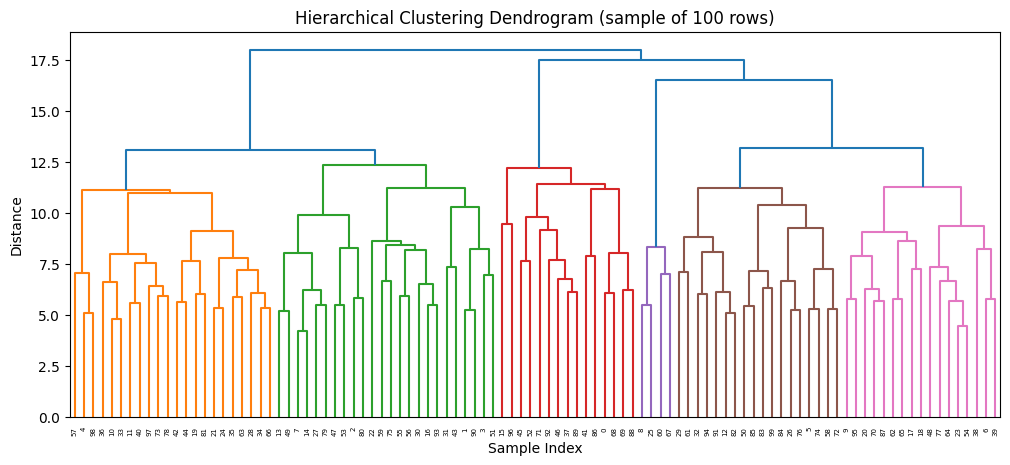

Hierarchical cluster distribution:
hc_cluster
1    513
0    454
2     38
Name: count, dtype: int64


In [19]:
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(12, 5))
sch.dendrogram(sch.linkage(x_reg_full_scaled[:100], method='ward'))
plt.title('Hierarchical Clustering Dendrogram (sample of 100 rows)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
df_cluster['hc_cluster'] = hc.fit_predict(x_reg_full_scaled)

print("Hierarchical cluster distribution:")
print(df_cluster['hc_cluster'].value_counts())

## 7. Regression: Predicting Academic Performance

The regression target is academic_performance, a continuous numerical variable. Two models are trained and evaluated: Linear Regression and Random Forest Regression. Performance is measured using MAE (Mean Absolute Error), RMSE (Root Mean Squared Error), and R2 score. MAE and RMSE represent average prediction error in original units (score points), while R2 measures how much variance in the target the model explains.

### 7.1 Linear Regression

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(x_train_reg_scaled, y_train_reg)
y_pred_lr = lr.predict(x_test_reg_scaled)

print("Linear Regression")
print("MAE :", round(mean_absolute_error(y_test_reg, y_pred_lr), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_reg, y_pred_lr)), 3))
print("R2  :", round(r2_score(y_test_reg, y_pred_lr), 3))

Linear Regression
MAE : 11.382
RMSE: 14.213
R2  : -0.046


### 7.2 Random Forest Regression

In [21]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(x_train_reg_scaled, y_train_reg)
y_pred_rf_reg = rf_reg.predict(x_test_reg_scaled)

print("Random Forest Regression")
print("MAE :", round(mean_absolute_error(y_test_reg, y_pred_rf_reg), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg)), 3))
print("R2  :", round(r2_score(y_test_reg, y_pred_rf_reg), 3))

Random Forest Regression
MAE : 11.287
RMSE: 14.229
R2  : -0.049


## 8. Classification: Predicting Addiction Category

The classification target is addiction_category_encoded, representing three levels of gaming addiction: Low (0), Medium (1), and High (2). Two classifiers are trained: Logistic Regression and Random Forest Classifier. Performance is evaluated using accuracy and a full classification report showing precision, recall, and F1 score per class.

### 8.1 Logistic Regression

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_clf = LogisticRegression(max_iter=1000, random_state=42)
log_clf.fit(x_train_clf_scaled, y_train_clf)
y_pred_log = log_clf.predict(x_test_clf_scaled)

print("Logistic Regression")
print("Accuracy:", round(accuracy_score(y_test_clf, y_pred_log), 4))
print(classification_report(y_test_clf, y_pred_log, target_names=['Low', 'Medium', 'High']))

Logistic Regression
Accuracy: 0.6716
              precision    recall  f1-score   support

         Low       0.75      0.84      0.79        69
      Medium       0.71      0.74      0.73        66
        High       0.51      0.42      0.46        66

    accuracy                           0.67       201
   macro avg       0.66      0.67      0.66       201
weighted avg       0.66      0.67      0.66       201



### 8.2 Random Forest Classifier

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(x_train_clf_scaled, y_train_clf)
y_pred_rf_clf = rf_clf.predict(x_test_clf_scaled)

print("Random Forest Classification")
print("Accuracy:", round(accuracy_score(y_test_clf, y_pred_rf_clf), 4))
print(classification_report(y_test_clf, y_pred_rf_clf, target_names=['Low', 'Medium', 'High']))

Random Forest Classification
Accuracy: 0.6468
              precision    recall  f1-score   support

         Low       0.73      0.80      0.76        69
      Medium       0.68      0.82      0.74        66
        High       0.45      0.32      0.37        66

    accuracy                           0.65       201
   macro avg       0.62      0.64      0.63       201
weighted avg       0.62      0.65      0.63       201



### 8.3 Confusion Matrix: Random Forest Classifier

The confusion matrix shows how many predictions fell into each category. Rows represent actual labels and columns represent predicted labels. The diagonal values indicate correct predictions.

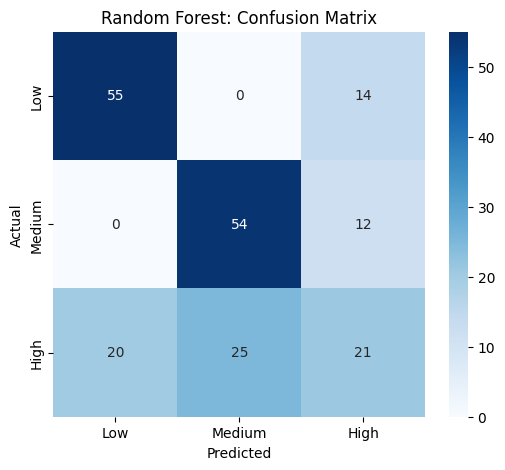

In [24]:
cm = confusion_matrix(y_test_clf, y_pred_rf_clf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.title('Random Forest: Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 9. Model Evaluation Summary

In [25]:
print('=' * 55)
print('  REGRESSION RESULTS: target: academic_performance')
print('=' * 55)
print(f"{'Model':<25} {'MAE':>8} {'RMSE':>8} {'R2':>8}")
print('-' * 55)
print(f"{'Linear Regression':<25} "
      f"{mean_absolute_error(y_test_reg, y_pred_lr):>8.3f} "
      f"{np.sqrt(mean_squared_error(y_test_reg, y_pred_lr)):>8.3f} "
      f"{r2_score(y_test_reg, y_pred_lr):>8.3f}")
print(f"{'Random Forest Reg.':<25} "
      f"{mean_absolute_error(y_test_reg, y_pred_rf_reg):>8.3f} "
      f"{np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg)):>8.3f} "
      f"{r2_score(y_test_reg, y_pred_rf_reg):>8.3f}")
print()
print('=' * 55)
print('  CLASSIFICATION RESULTS: target: addiction_category')
print('=' * 55)
print(f"{'Model':<25} {'Accuracy':>10}")
print('-' * 55)
print(f"{'Logistic Regression':<25} {accuracy_score(y_test_clf, y_pred_log):>10.4f}")
print(f"{'Random Forest Clf.':<25} {accuracy_score(y_test_clf, y_pred_rf_clf):>10.4f}")

  REGRESSION RESULTS: target: academic_performance
Model                          MAE     RMSE       R2
-------------------------------------------------------
Linear Regression           11.382   14.213   -0.046
Random Forest Reg.          11.287   14.229   -0.049

  CLASSIFICATION RESULTS: target: addiction_category
Model                       Accuracy
-------------------------------------------------------
Logistic Regression           0.6716
Random Forest Clf.            0.6468


## 10. Conclusion

This project analyzed a dataset of 1005 gamers to investigate the impact of gaming behavior on academic and psychological outcomes.

**Preprocessing** involved encoding the gender feature using OneHotEncoder, binning the continuous addiction_level into three balanced categories (Low, Medium, High) using quantile-based boundaries, and applying StandardScaler separately to training and test sets to prevent data leakage.

**Clustering** with K-Means (K=3) produced three relatively balanced groups. Hierarchical clustering identified a similar structure, with one notably small cluster (approximately 38 rows) suggesting a distinct subgroup of users with unusual gaming patterns.

**Regression** results showed negative R2 scores for both Linear Regression and Random Forest Regression. This indicates that academic performance cannot be reliably predicted from gaming features alone in this dataset, which is consistent with the very low correlation values observed in the EDA phase.

**Classification** results showed that Logistic Regression (67.2% accuracy) slightly outperformed Random Forest (64.7% accuracy) in predicting addiction category. Both models performed best on the Low class and worst on the High class, suggesting that highly addicted users display more varied behavioral patterns.

**Challenges** included handling the imbalanced distribution of addiction_level (most users scored below 3 out of 10), managing data leakage risks between related features, and the absence of strong predictive signals for academic performance in the available features.